# Advanced Cybersecurity Dataset Analysis (NSL-KDD)

This notebook performs an in-depth exploratory data analysis (EDA) on the **NSL-KDD** intrusion detection dataset.

Features:
- Automatic dataset download
- Data cleaning and preprocessing
- Advanced visualizations
- Security-focused insights

Dataset source: NSL-KDD (public benchmark dataset for intrusion detection)

## 1. Imports

In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Download Dataset Automatically

In [37]:

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.csv"

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
    'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

df = pd.read_csv(url, names=columns)
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Dataset Overview

In [9]:

df.shape


(125973, 43)

In [11]:

df['label'].value_counts().head(10)


label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

## 4. Attack Category Mapping

In [14]:

attack_map = {
    'normal': 'Normal',
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS', 'pod': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe',
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R'
}

df['attack_category'] = df['label'].map(attack_map)
df['attack_category'].value_counts()


attack_category
Normal    67343
DoS       45909
Probe     11656
R2L         993
U2R          49
Name: count, dtype: int64

## 5. Visualization: Attack Category Distribution

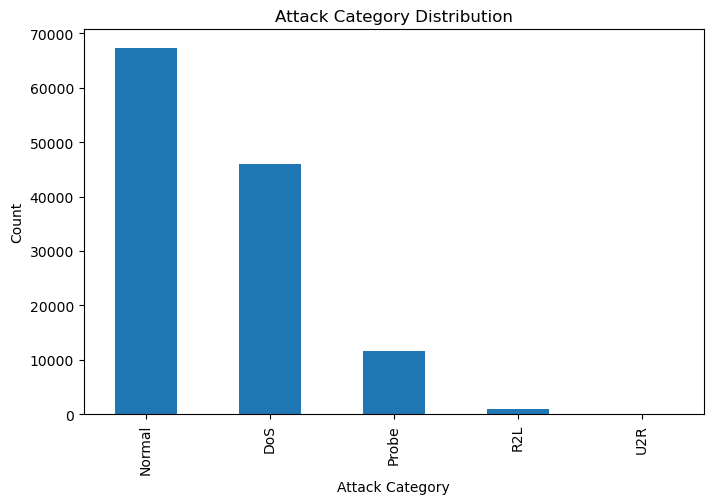

In [17]:

plt.figure(figsize=(8,5))
df['attack_category'].value_counts().plot(kind='bar')
plt.title("Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.show()


## 6. Visualization: Protocol vs Attack Category

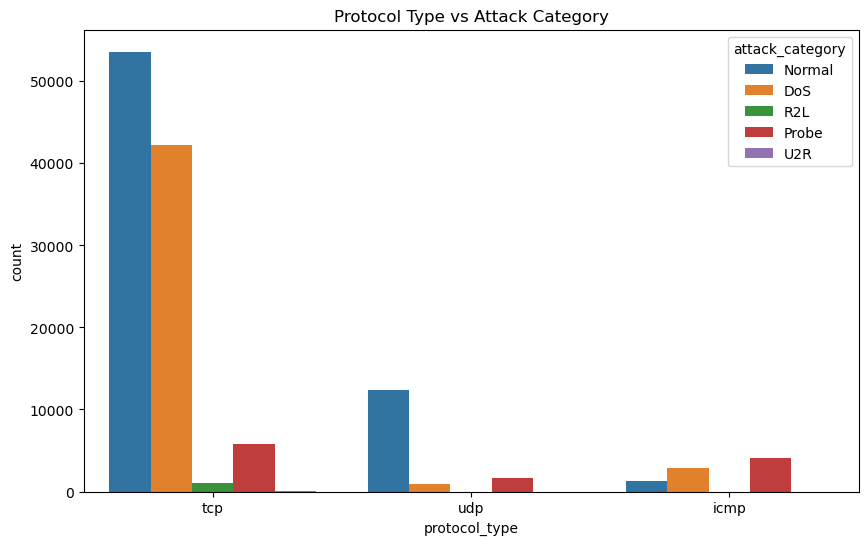

In [20]:

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='protocol_type', hue='attack_category')
plt.title("Protocol Type vs Attack Category")
plt.show()


## 7. Correlation Heatmap (Numerical Features)

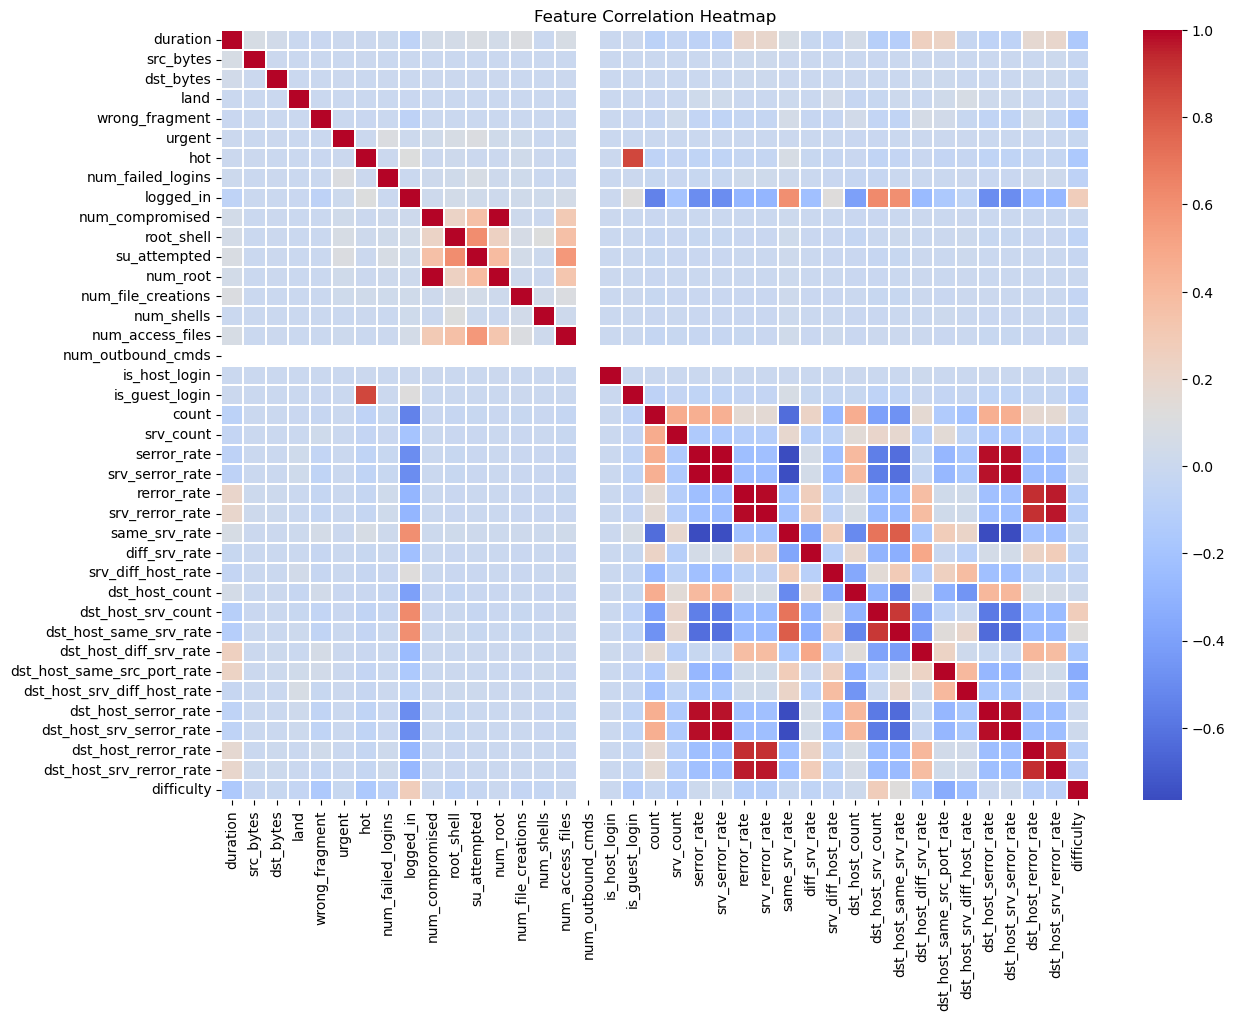

In [23]:

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.1)
plt.title("Feature Correlation Heatmap")
plt.show()


## 8. Bytes Transferred vs Attack Category

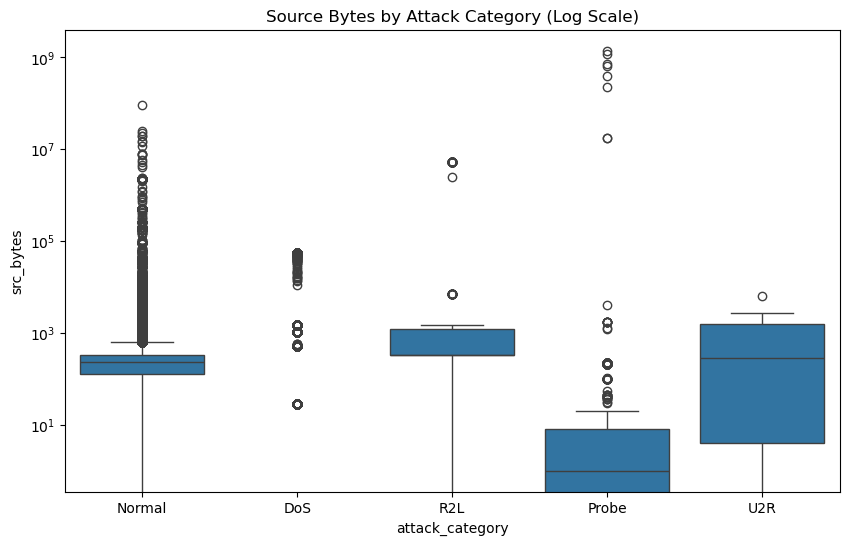

In [25]:

plt.figure(figsize=(10,6))
sns.boxplot(x='attack_category', y='src_bytes', data=df)
plt.yscale('log')
plt.title("Source Bytes by Attack Category (Log Scale)")
plt.show()


## 9. Conclusion

This notebook demonstrates how real-world cybersecurity datasets can be analyzed using Python.

**Key takeaways:**
- DoS attacks dominate the NSL-KDD dataset
- Certain protocols are more associated with specific attack types
- Feature correlations can inform intrusion detection models